## Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import scipy.linalg as linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
#import preprocess


device = 'cuda:1'

%load_ext autoreload
%autoreload 2

## Data generation

In [2]:
from datasets import NonlinearGaussian, MoG

n, d = 10000, 64                                 # < higher d, higher MI
true_rho = 0.7                                   # < higher rho, higher MI
case = '3a'                                      # < choose between ['1a', '1b', '2', '3a', '3b', '3c', 'MoG']

if case != 'MoG':
    dataset = NonlinearGaussian.NonlinearGaussian(n_samples=n, n_dims=d, rho=true_rho, mu=0, case=case)
    X0, Y0 = dataset.sample_data(n_samples = n)
    X, Y = dataset.transformation(X0, Y0)
    MI = dataset.true_mutual_info()              # we know GT MI
else:
    dataset = MoG.MoG(n_samples=n, n_dims=d, K=5, shifts=[-0.4, -0.1, 0, 0.1, 0.4], rhos=[0.5, 0.6, 0.7, 0.8, 0.9])
    X, Y = dataset.sample_data(n_samples = n)
    MI = dataset.empirical_mutual_info()         # MI by MC estimate

X, Y = X.to(device), Y.to(device)
Z = torch.cat([X, Y], dim=1)
T = torch.ones(n, 2).to(device)

print('X size=', X.size(), 'Y size=', Y.size())
print("True MI is", MI)

X size= torch.Size([10000, 32]) Y size= torch.Size([10000, 32])
True MI is 10.77351285222025


## Train the VCE estimator

In [3]:
class Hyperparams(object):
    def __init__(self): 
        self.critic = 'neural'                # ('neural', 'quadratic')
        self.lr = 5e-4
        self.bs = 500
        self.n_bridges = 4
        self.wd = 1e-5
        self.max_iteration = 1250
        
hyperparams=Hyperparams()

architecture_critic = [d, 500, 500, 500, 1]

In [6]:
## Neural adaptive MI estimate
from estimators.VCE import VCE

estimator = VCE(None, None, architecture_critic, hyperparams)
estimator.to(device)
estimator.learn(X, Y)

print('true MI:', MI)
print('est MI:', estimator.MI(X, Y))

K components= 5 copula transform= True
nde type: FM
finished: t= 0 loss= 1.0794113874435425 loss val= 1.0577415227890015 best val loss= 1.0577415227890015 best t= 0
finished: t= 126 loss= 0.20618242025375366 loss val= 0.19488349556922913 best val loss= 0.19105634093284607 best t= 116
finished: t= 252 loss= 0.1926165372133255 loss val= 0.19155341386795044 best val loss= 0.18569320440292358 best t= 177
finished: t= 378 loss= 0.18494866788387299 loss val= 0.19671258330345154 best val loss= 0.18397913873195648 best t= 372
finished: t= 504 loss= 0.17457041144371033 loss val= 0.18558645248413086 best val loss= 0.18007831275463104 best t= 435
finished: t= 630 loss= 0.18763455748558044 loss val= 0.18576137721538544 best val loss= 0.17044401168823242 best t= 597
finished: t= 756 loss= 0.18115206062793732 loss val= 0.18819847702980042 best val loss= 0.17044401168823242 best t= 597
finished: t= 882 loss= 0.18498538434505463 loss val= 0.18260818719863892 best val loss= 0.17044401168823242 best t= 

### Check the computed vector ranks

In [5]:
import torch.distributions as distribution

XX, YY = estimator.forward(X, Y)

# Compute empirical ranks
sorted_data, idx = torch.sort(XX, dim=0)
_, idx2 = torch.sort(idx, dim=0)
U = (idx2.float()+1)/(len(XX)+1)   

# Compute covariance
zeros, ones = torch.zeros(XX.size()).to(XX.device), torch.ones(XX.size()).to(XX.device)
U = (U-U.mean(keepdim=True, dim=0))/U.std(keepdim=True, dim=0)


V = torch.matmul(U.t(), U)/(len(U)+1)

### Visualizing the distributions of non-diagonal elements

mean abs 0.01869279275956521
q5 -0.029201321303844452
q95 0.032012179493904114


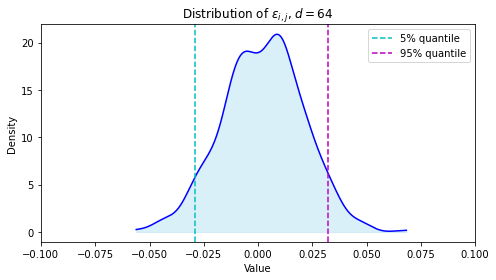

In [7]:
from scipy.stats import gaussian_kde


# Get non-diagonal elements of covariance matrices
non_diag_mask = ~torch.eye(V.size(0), dtype=bool, device=V.device)
non_diag_values = V[non_diag_mask]

# Convert to numpy
non_diag_np = non_diag_values.cpu().numpy()
sorted_vals = np.sort(non_diag_np)

# Compute ranks
L = len(sorted_vals)
q5, q95 = sorted_vals[int(L * 0.05)], sorted_vals[int(L * 0.95)]
print('mean abs', (sorted_vals**2).mean()**0.5)
print('q5', q5.item())
print('q95', q95.item())

# KDE with scipy
kde = gaussian_kde(non_diag_np)
x_vals = np.linspace(min(non_diag_np), max(non_diag_np), 1000)
density = kde(x_vals)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(x_vals, density, color='blue')
plt.fill_between(x_vals, density, alpha=0.3, color='skyblue')
plt.axvline(q5, color='c', linestyle='--', label='5% quantile')
plt.axvline(q95, color='m', linestyle='--', label='95% quantile')
plt.title(r'Distribution of $\epsilon_{i, j}$, $d=64$')
plt.xlim(-0.10, 0.10)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()